In [ ]:
# !gdown 1Z0JINntfOKyL6gHfnWg7rNkFSI_WgCw2  (data file for this project)

## Project goal

The goal of the visualization is to identify patterns that influence the decision to issue a loan, as well as to evaluate the quality and balance the data.

During the visual analysis, I want to:
Analyze incomes: look at applicant incomes and find outliers that might confuse the model.

Visualize the number of loan approvals and rejections.

See how education affects loan approval.

Find the relationship between loan approval and income: determine if there is a dependence on how much a person earns and whether they get their loan approved.

## Data Preparation

Data processing, outlier removal and filling missing values

In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer
df = pd.read_csv('credit.csv')
df = df.drop(columns=['Loan_ID'])
df['Dependents'] = df['Dependents'].replace('3+', 3)
imputer_num = SimpleImputer(strategy='mean')
df[['LoanAmount', 'Loan_Amount_Term', 'Credit_History']] = imputer_num.fit_transform(df[['LoanAmount', 'Loan_Amount_Term', 'Credit_History']])
imputer_cat = SimpleImputer(strategy='most_frequent')
df[['Gender', 'Married', 'Self_Employed']] = imputer_cat.fit_transform(df[['Gender', 'Married', 'Self_Employed']])
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
print(df.head())

  Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0   Male      No          0      Graduate            No             5849   
1   Male     Yes          1      Graduate            No             4583   
2   Male     Yes          0      Graduate           Yes             3000   
3   Male     Yes          0  Not Graduate            No             2583   
4   Male      No          0      Graduate            No             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0  146.412162             360.0             1.0   
1             1508.0  128.000000             360.0             1.0   
2                0.0   66.000000             360.0             1.0   
3             2358.0  120.000000             360.0             1.0   
4                0.0  141.000000             360.0             1.0   

  Property_Area Loan_Status  Total_Income  
0         Urban           Y        5849.0  
1         Rural           N       

## Choice of visualization types

For the analysis of the credit dataset, I chose the following types of visualization:

histogram - "Income dependence"

bar chart - "Loan approval/rejection"

boxplot - "Income outlier"

pie chart - "Client education"

## Building visualizations

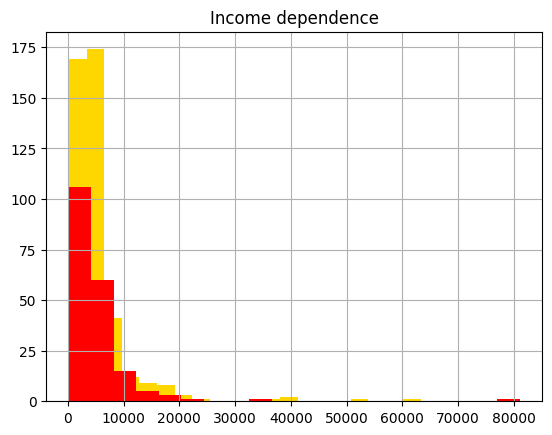

In [7]:
import matplotlib.pyplot as plt
df[df['Loan_Status']=='Y']['ApplicantIncome'].hist(bins=20, color='gold')
df[df['Loan_Status']=='N']['ApplicantIncome'].hist(bins=20, color='red')
plt.title('Income dependence')
plt.show()

## Visualization of loan approvals:

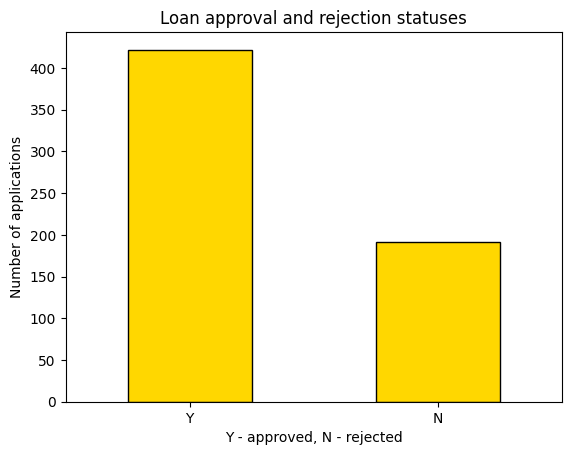

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('credit.csv')
df['Loan_Status'].value_counts().plot(kind='bar', color='gold', edgecolor='black')
plt.title('Loan approval and rejection statuses')
plt.xlabel('Y - approved, N - rejected')
plt.ylabel('Number of applications')
plt.xticks(rotation=0)
plt.show()

## Analysis of income outliers:

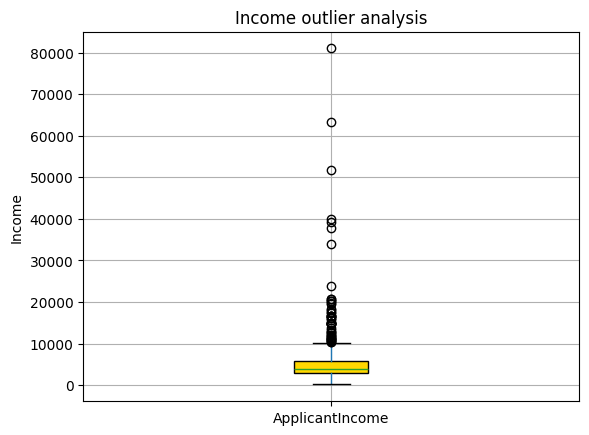

In [16]:
import matplotlib.pyplot as plt
df.boxplot(column='ApplicantIncome', patch_artist=True, 
           boxprops=dict(facecolor='gold', color='black'))
plt.title('Income outlier analysis')
plt.ylabel('Income')
plt.show()

## Analysis of education among people in the dataset

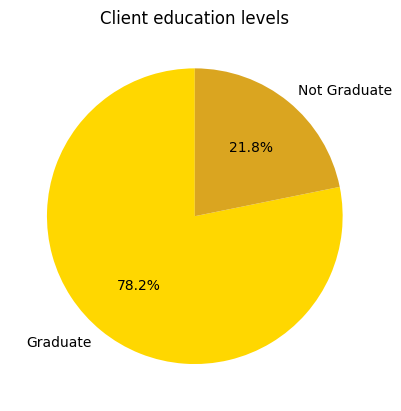

In [19]:
import matplotlib.pyplot as plt
df['Education'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['gold', '#DAA520'], startangle=90)
plt.title('Client education levels')
plt.show()

## Conclusions

Incomes: the majority of people have an income of up to 20000$. In the "Analysis of income outliers" chart, big outliers are visible; there are clients with giant incomes

Approval: loans are approved more often than they are rejected

Education: most of the clients are educated people and their number is several times higher than the number of clients without education

Final conclusion: if a person is educated and got high income, getting a loan will be easier.